# Hierarchy Clustering

"agglomerative clustering" or "bottom-up clustering"

Visualized in a dendrogram

In [1]:
# Cluster the iris dataset and provide a dendrogram

from sklearn.datasets import load_iris
iris = load_iris()

import pandas as pd

# Create a dataframe with the four feature variables
df = pd.DataFrame(iris.data, columns=iris.feature_names)

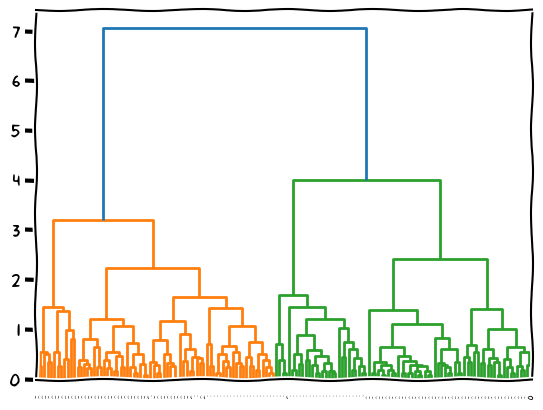

In [2]:
# Create the dendrogram with the linkage method
from matplotlib import pyplot as plt
plt.xkcd()

from scipy.cluster.hierarchy import linkage, dendrogram

mergings = linkage(df, method='complete')
dendrogram(mergings,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=6)

plt.title('Hierarchical Clustering Dendrogram (method=complete)')
plt.show()

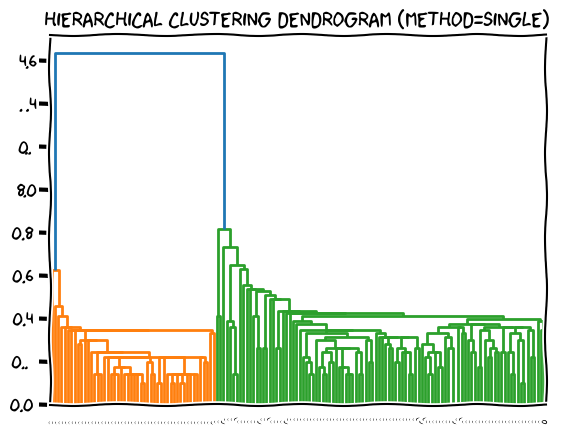

In [5]:
mergings = linkage(df, method='single')
dendrogram(mergings,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=6)

plt.title('Hierarchical Clustering Dendrogram (method=single)')
plt.show()

In [3]:
# Extract the cluster labels using `fcluster`

from scipy.cluster.hierarchy import fcluster

mergings = linkage(df, method='complete')
labels = fcluster(mergings, 3, criterion='distance')

print(labels)

[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 2 2 2 3 2 3 2 3 2 3 3 3 3 2 3 2 3 3 2 3 2 3 2 2
 2 2 2 2 2 3 3 3 3 2 3 2 2 2 3 3 3 2 3 3 3 3 3 2 3 3 2 2 1 2 2 1 3 1 2 1 2
 2 2 2 2 2 2 1 1 2 2 2 1 2 2 1 2 2 2 1 1 1 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
pairs = pd.DataFrame({'labels': labels, 'species': iris.target})

print(pairs.sort_values('labels'))

     labels  species
117       1        2
118       1        2
109       1        2
107       1        2
122       1        2
..      ...      ...
29        4        0
28        4        0
27        4        0
37        4        0
0         4        0

[150 rows x 2 columns]


In [7]:
ct = pd.crosstab(pairs['labels'], pairs['species'])

print(ct)

species   0   1   2
labels             
1         0   0  12
2         0  23  37
3         0  27   1
4        50   0   0
